# Log
## 16/2/26
Lstm is overfitting on training data significantly, leading to an MSE loss on returns of >1 on the validation set (i.e. worse than random guessing). 

In [10]:
# Load data and convert date string to datetime data
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../data/portfolio_data.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df = df.set_index("Date")

df_returns = df.copy()
stock_cols = ['AMZN', 'DPZ', 'BTC', 'NFLX']

# Compute daily returns
df_returns[stock_cols] = df_returns[stock_cols].pct_change()
df_returns = df_returns.dropna()
df_returns.head()


,AMZN,DPZ,BTC,NFLX
Date,,,,
2013-05-02,0.017403,0.015556,-0.076706,0.007421
2013-05-03,0.021778,0.008830,0.150867,-0.004849
2013-05-06,-0.009029,0.014469,-0.029229,-0.012930
2013-05-07,0.007860,0.017785,0.032847,-0.021074
2013-05-08,0.003686,0.004325,-0.003534,0.011442


In [11]:
# Scale asset values between -1 and 1
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_returns[stock_cols])

In [12]:
# Split time series data into training samples
import numpy as np

def create_sequences(data, window_size=30):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, window_size=90)

In [ ]:
# Train/val split WITHOUT shuffling (as we're dealing with sequential time series data)
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

SyntaxError: invalid syntax (1346420188.py, line 6)

In [14]:
# Baseline prediction
y_pred_baseline = X_val[:, -1, :] # Last day in each window

# Compare with true y
from sklearn.metrics import mean_squared_error

mse_baseline = mean_squared_error(y_val, y_pred_baseline)
mse_baseline

2.08631077347658

In [15]:
# LSTM
import tensorflow

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(32, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(len(stock_cols))
])

model.compile(
    optimizer="Adam",
    loss="mse"
)

model.summary()

/opt/homebrew/Caskroom/miniforge/base/envs/stock-lstm/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,868 (19.02 KB)

 Trainable params: 4,868 (19.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early Stopping

In [16]:
# Fit the LSTM

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1.0540 - val_loss: 0.9963
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.0390 - val_loss: 0.9910
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.0366 - val_loss: 0.9869
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.0314 - val_loss: 0.9861
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.0249 - val_loss: 0.9871
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.0254 - val_loss: 0.9868
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.0245 - val_loss: 0.9853
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.0179 - val_loss: 0.9866
Epoch 9/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.0137 - val_loss: 0.9885
Epoch 10/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.0078 - val_loss: 0.9897
Epoch 11/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.0071 - val_loss: 0.9892
Epoch 12/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.0

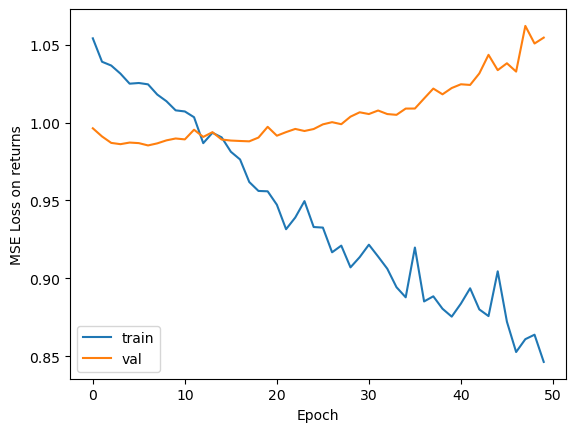

In [17]:
# Plot training vs validation loss

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss on returns')
plt.legend()
plt.show()

In [18]:
# Make predictions

y_pred = model.predict(X_val)

# Evaluate predictions

mse_lstm = mean_squared_error(y_val, y_pred)
print('LSTM MSE: ', mse_lstm)
# Per-stock MSE
for i, col in enumerate(['AMZN', 'DPZ', 'BTC', 'NFLX']):
    mse = mean_squared_error(y_val[:, i], y_pred[:, i])
    print(f"{col} MSE: {mse:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
LSTM MSE:  1.0544901166036886
AMZN MSE: 1.4693
DPZ MSE: 1.3980
BTC MSE: 0.1931
NFLX MSE: 1.1576
